In [1]:
import os
import pandas as pd

from tqdm import tqdm

In [2]:
data_root = "../../2014-citibike-tripdata/"

all_partitions = []

for root, dirs, files in tqdm(os.walk(data_root)):
    for fn in files:
        if fn.endswith(".csv"):
            parent_name = os.path.basename(root)
            df = pd.read_csv(os.path.join(root, fn))
            df["Partition"] = parent_name
            all_partitions.append(df)

df = pd.concat(all_partitions, ignore_index=True)

13it [00:08,  1.53it/s]


In [3]:
df['bikeid'].unique()

array([21062, 20229, 20922, ..., 15507, 20250, 18052], shape=(6811,))

In [4]:
import seaborn as sns

In [6]:
df

,tripduration,starttime,stoptime,start station id,start station name,start station latitude,start station longitude,end station id,end station name,end station latitude,end station longitude,bikeid,usertype,birth year,gender,Partition
0,558,2014-04-01 00:00:07,2014-04-01 00:09:25,82,St James Pl & Pearl St,40.711174,-74.000165,2008,Little West St & 1 Pl,40.705693,-74.016777,21062,Subscriber,1982,1,4_April
1,882,2014-04-01 00:00:20,2014-04-01 00:15:02,349,Rivington St & Ridge St,40.718502,-73.983299,312,Allen St & E Houston St,40.722055,-73.989111,20229,Subscriber,1988,1,4_April
2,587,2014-04-01 00:00:25,2014-04-01 00:10:12,293,Lafayette St & E 8 St,40.730287,-73.990765,334,W 20 St & 7 Ave,40.742388,-73.997262,20922,Subscriber,1959,1,4_April
3,355,2014-04-01 00:00:44,2014-04-01 00:06:39,539,Metropolitan Ave & Bedford Ave,40.715348,-73.960241,282,Kent Ave & S 11 St,40.708273,-73.968341,20914,Subscriber,1981,1,4_April
4,524,2014-04-01 00:01:29,2014-04-01 00:10:13,459,W 20 St & 11 Ave,40.746745,-74.007756,503,E 20 St & Park Ave,40.738274,-73.987520,21051,Subscriber,1964,1,4_April
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8081211,261,2014-05-31 23:59:37,2014-06-01 00:03:58,527,E 33 St & 1 Ave,40.743156,-73.974347,507,E 25 St & 2 Ave,40.739126,-73.979738,14542,Customer,\N,0,5_May
8081212,735,2014-05-31 23:59:42,2014-06-01 00:11:57,463,9 Ave & W 16 St,40.742065,-74.004432,483,E 12 St & 3 Ave,40.732233,-73.988900,19133,Subscriber,1989,1,5_May
8081213,489,2014-05-31 23:59:43,2014-06-01 00:07:52,368,Carmine St & 6 Ave,40.730386,-74.002150,328,Watts St & Greenwich St,40.724055,-74.009660,14886,Subscriber,1981,1,5_May
8081214,442,2014-05-31 23:59:54,2014-06-01 00:07:16,403,E 2 St & 2 Ave,40.725029,-73.990697,293,Lafayette St & E 8 St,40.730287,-73.990765,15900,Subscriber,1989,1,5_May


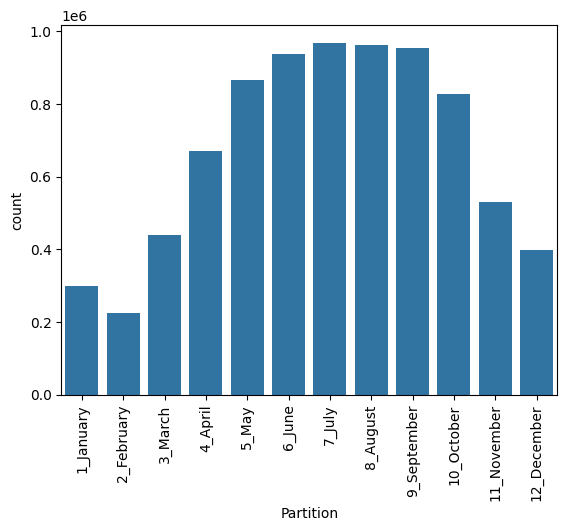

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# define month order explicitly
month_order = [
    "1_January", "2_February", "3_March", "4_April",
    "5_May", "6_June", "7_July", "8_August",
    "9_September", "10_October", "11_November", "12_December"
]

# plot with custom order
sns.countplot(data=df, x="Partition", order=month_order)

plt.xticks(rotation=90)
plt.savefig("data_distribution.pdf", bbox_inches='tight')

/var/folders/r5/9j5y699n711bxc83m5pqqtrc0000gn/T/ipykernel_56155/1025670509.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['tripduration_min'] = df['tripduration'] / 60.0
/var/folders/r5/9j5y699n711bxc83m5pqqtrc0000gn/T/ipykernel_56155/1025670509.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hour'] = df['starttime'].dt.hour
/var/folders/r5/9j5y699n711bxc83m5pqqtrc0000gn/T/ipykernel_56155/1025670509.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a Da

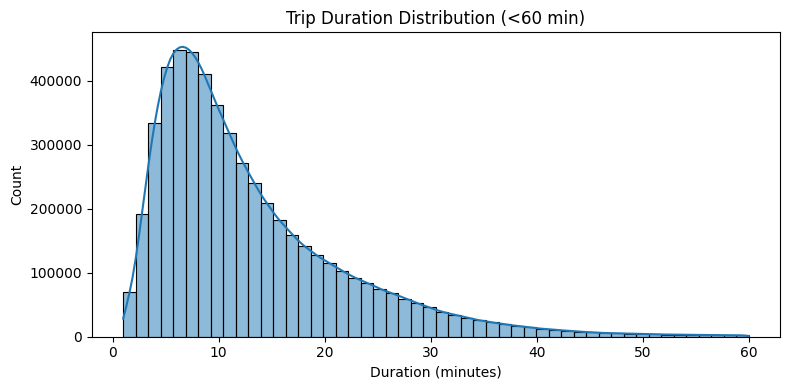

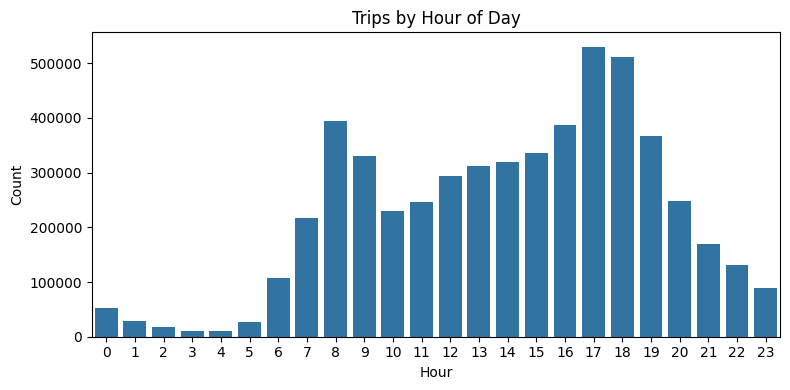

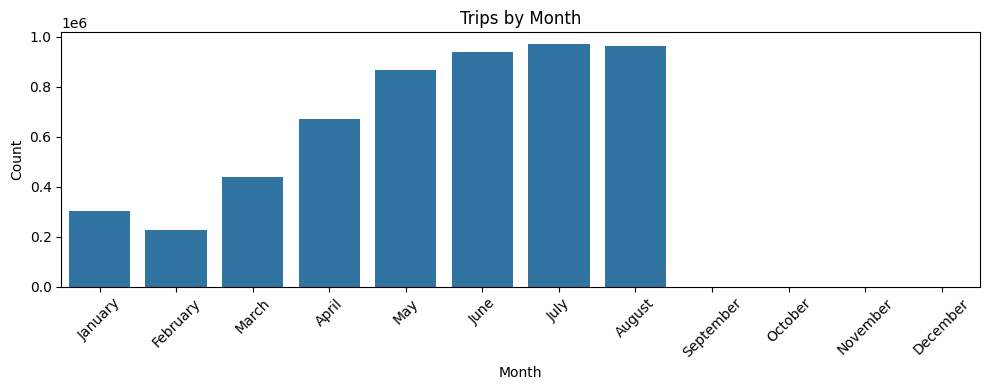

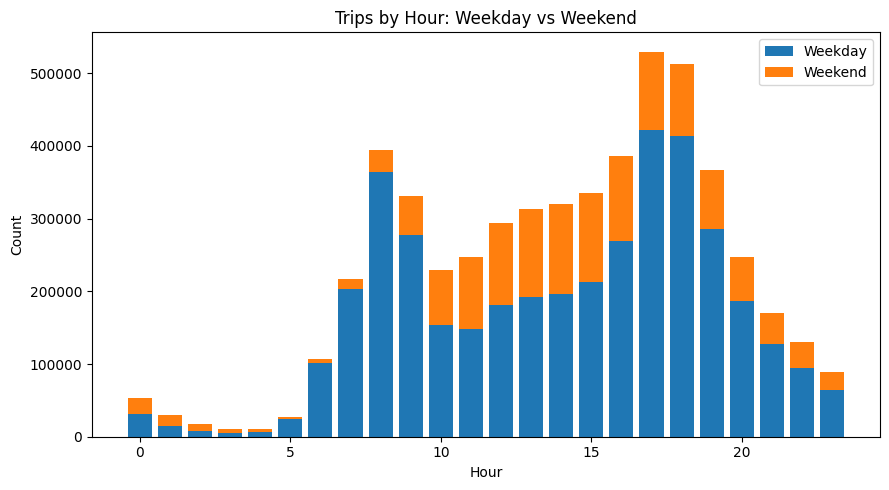

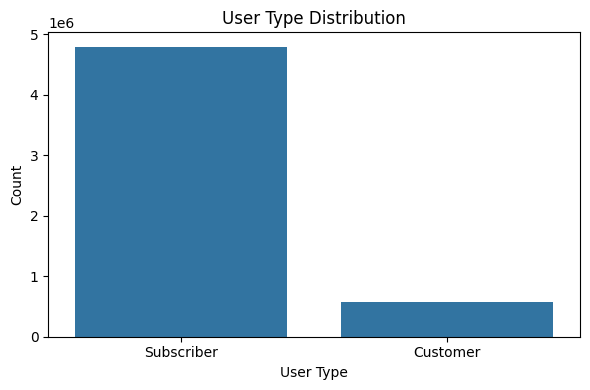

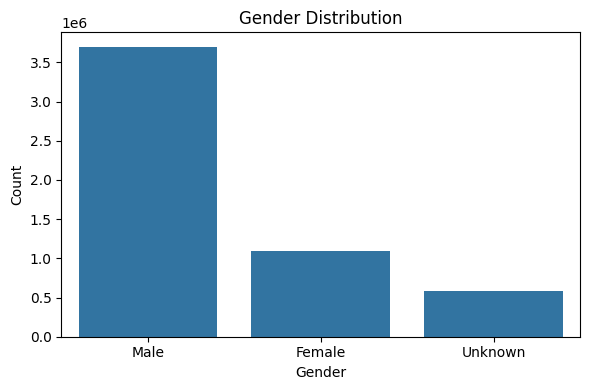

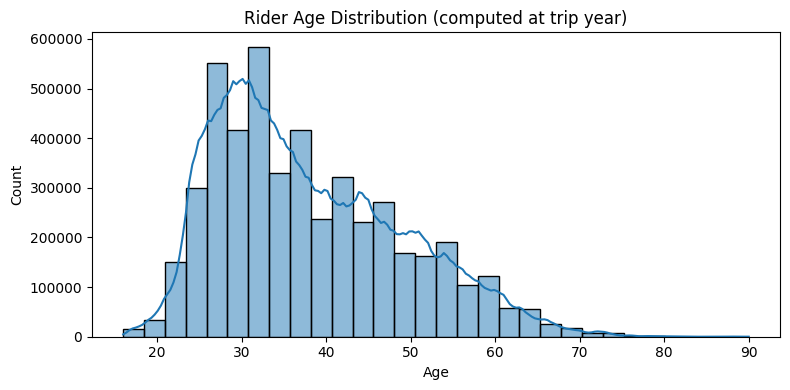

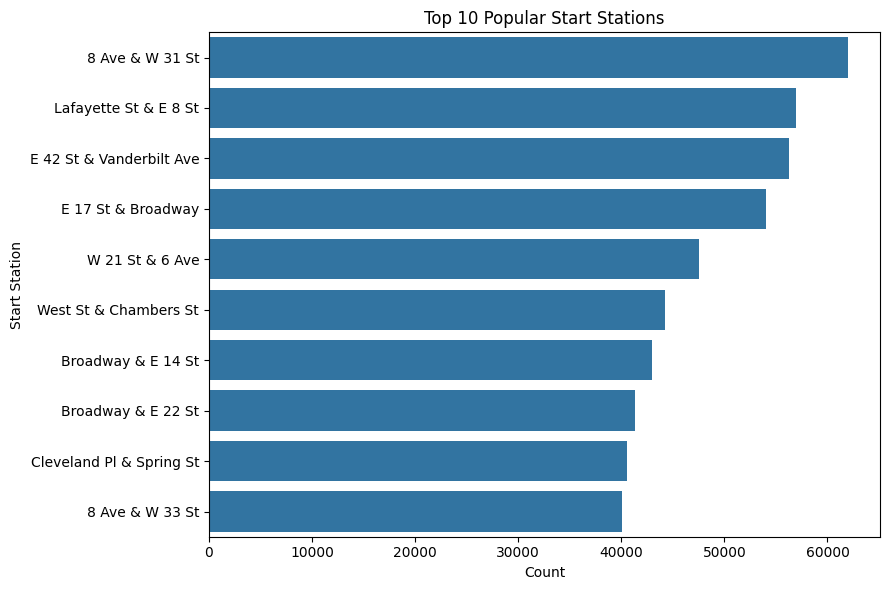

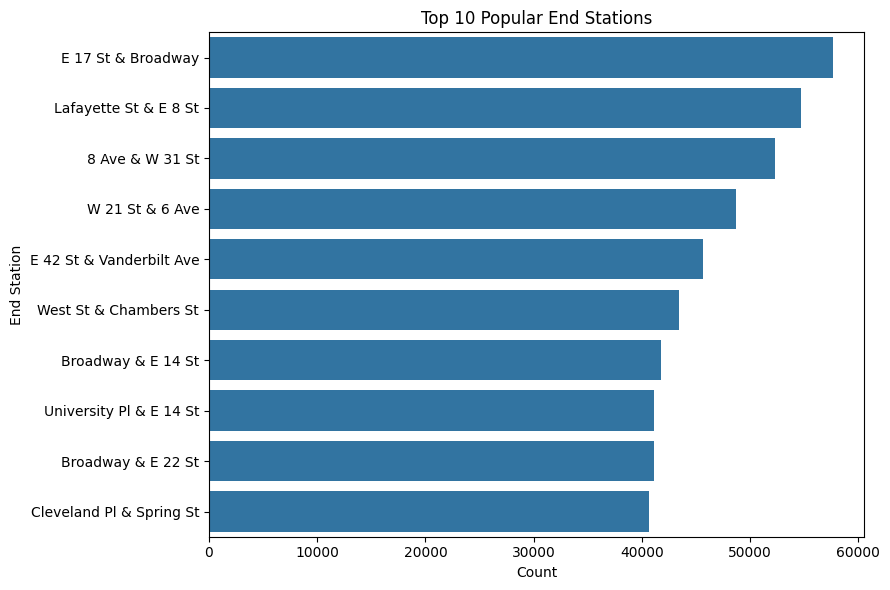

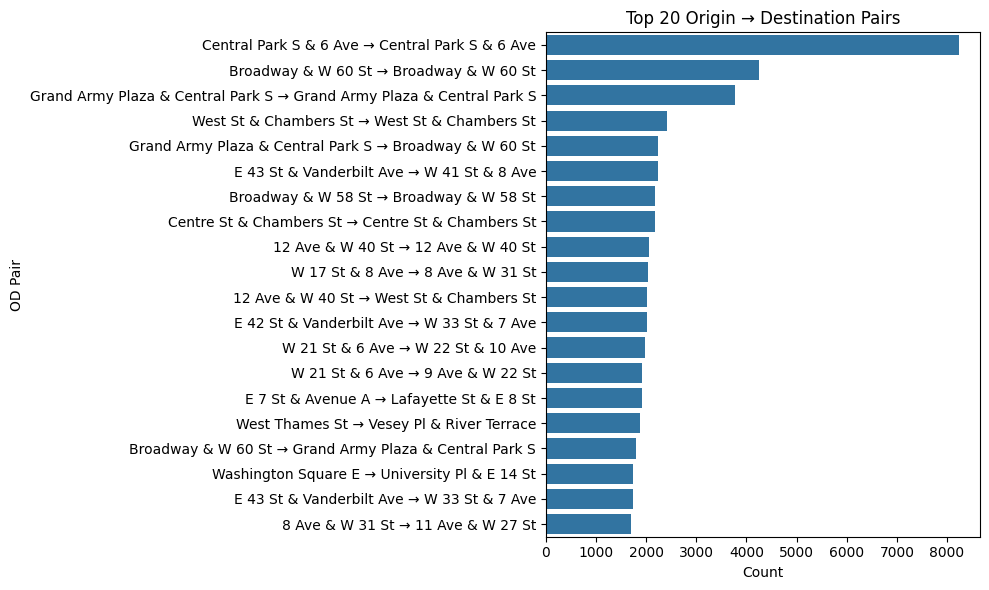

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1) Load & parse ---
# If your file is named "bikeshare.csv", use this:
# df = pd.read_csv("bikeshare.csv")

# If you already have a DataFrame named df, skip the read_csv line above.
# Parse times; the sample looks like MM/DD/YYYY HH:MM:SS so set dayfirst=False.
df['starttime'] = pd.to_datetime(df['starttime'], dayfirst=False, errors='coerce')
df['stoptime']  = pd.to_datetime(df['stoptime'],  dayfirst=False, errors='coerce')

# Drop rows with invalid times if any
df = df.dropna(subset=['starttime', 'stoptime'])

# --- 2) Feature engineering ---
# Trip duration in minutes; your CSV has seconds in 'tripduration'
df['tripduration_min'] = df['tripduration'] / 60.0

# Hour of day
df['hour'] = df['starttime'].dt.hour

# Weekday (0=Mon,...,6=Sun) and weekend flag
df['weekday'] = df['starttime'].dt.weekday
df['is_weekend'] = df['weekday'].isin([5, 6]).map({True: 'Weekend', False: 'Weekday'})

# Month as natural month names with order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]
df['month_name'] = pd.Categorical(df['starttime'].dt.month_name(), categories=month_order, ordered=True)

# Rider age at trip time (use trip year instead of current year)
# Note: 'birth year' may be float; convert safely
df['birth year'] = pd.to_numeric(df['birth year'], errors='coerce')
df['age'] = df['starttime'].dt.year - df['birth year']

# Gender mapping (0=Unknown, 1=Male, 2=Female) — common in bikeshare datasets
gender_map = {0: 'Unknown', 1: 'Male', 2: 'Female'}
df['gender_label'] = df['gender'].map(gender_map).fillna('Unknown')

# --- 3) Plots ---

# 3.1 Trip duration distribution (cap at <60 min to avoid extreme tails)
plt.figure(figsize=(8,4))
sns.histplot(df[df['tripduration_min'] < 60]['tripduration_min'], bins=50, kde=True)
plt.title("Trip Duration Distribution (<60 min)")
plt.xlabel("Duration (minutes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3.2 Trips by hour of day
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='hour', order=list(range(24)))
plt.title("Trips by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3.3 Trips by month (calendar order)
plt.figure(figsize=(10,4))
sns.countplot(data=df, x='month_name', order=month_order)
plt.title("Trips by Month")
plt.xlabel("Month")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3.4 Weekday vs weekend comparison (stacked by hour)
# Create a pivot for hour x is_weekend
hour_week = df.pivot_table(index='hour', columns='is_weekend', values='bikeid', aggfunc='count').fillna(0)
hour_week = hour_week.reindex(range(24)).fillna(0)

plt.figure(figsize=(9,5))
# Stacked bars for readability
plt.bar(hour_week.index, hour_week.get('Weekday', 0), label='Weekday')
plt.bar(hour_week.index, hour_week.get('Weekend', 0), bottom=hour_week.get('Weekday', 0), label='Weekend')
plt.title("Trips by Hour: Weekday vs Weekend")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.legend()
plt.tight_layout()
plt.show()

# 3.5 User type distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='usertype', order=df['usertype'].value_counts().index)
plt.title("User Type Distribution")
plt.xlabel("User Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3.6 Gender distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='gender_label', order=['Male','Female','Unknown'])
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3.7 Age distribution (reasonable human range filter)
plt.figure(figsize=(8,4))
age_mask = (df['age'] >= 10) & (df['age'] <= 90)
sns.histplot(df.loc[age_mask, 'age'], bins=30, kde=True)
plt.title("Rider Age Distribution (computed at trip year)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3.8 Top 10 popular start stations
plt.figure(figsize=(9,6))
top_start = df['start station name'].value_counts().head(10)
sns.barplot(x=top_start.values, y=top_start.index)
plt.title("Top 10 Popular Start Stations")
plt.xlabel("Count")
plt.ylabel("Start Station")
plt.tight_layout()
plt.show()

# 3.9 Top 10 popular end stations
plt.figure(figsize=(9,6))
top_end = df['end station name'].value_counts().head(10)
sns.barplot(x=top_end.values, y=top_end.index)
plt.title("Top 10 Popular End Stations")
plt.xlabel("Count")
plt.ylabel("End Station")
plt.tight_layout()
plt.show()

# 3.10 OD pair heat (top 20 pairs) — gives a quick sense of flows
od = (df
      .assign(od_pair=df['start station name'].astype(str) + " → " + df['end station name'].astype(str))
      ['od_pair'].value_counts().head(20))
plt.figure(figsize=(10,6))
sns.barplot(x=od.values, y=od.index)
plt.title("Top 20 Origin → Destination Pairs")
plt.xlabel("Count")
plt.ylabel("OD Pair")
plt.tight_layout()
plt.show()
